# 🎮 Regression Project — Part 2: Model Training & Evaluation
### Predicting Indie Game Review Scores with Machine Learning
---
> **How to use this notebook:** All code is hidden by default to keep the focus on results and insights. Click **"Show / Hide Code"** at the top of any section to reveal the implementation details.
>
> This is **Part 2** of a two-part notebook series. Part 1 (EDA) explored the dataset and identified key patterns. Here we build, train, and evaluate multiple regression models to predict the **Wilson lower bound review score** of Steam indie games using pre-release and structural game features.
>
> **Research question:** Do games released after the ChatGPT launch (November 2022) receive systematically different review scores, controlling for other pre-release features?
---

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Presentation CSS + Toggle Button
# Works in JupyterLab, Classic Notebook, and VS Code Jupyter
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript

display(Javascript(r"""
(function() {

// ── 1. Inject CSS into the main document head ────────────────────────────────
var css = `
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Fira+Code:wght@400;500&display=swap');

  :root {
    --g50:#f0fdf4; --g100:#dcfce7; --g200:#bbf7d0; --g400:#4ade80;
    --g500:#22c55e; --g600:#16a34a; --g700:#15803d; --g800:#166534; --g900:#14532d;
    --s50:#f8fafc;  --s100:#f1f5f9; --s200:#e2e8f0;
    --s600:#475569; --s700:#334155; --s800:#1e293b; --s900:#0f172a;
  }

  /* ── Notebook background ── */
  .jp-Notebook, #notebook-container, .notebook_app {
    background: var(--s50) !important;
  }

  /* ── Markdown typography ── */
  .jp-MarkdownOutput, .rendered_html, .text_cell_render {
    font-family: 'Inter', sans-serif !important;
    color: var(--s800); line-height: 1.75;
  }
  .jp-MarkdownOutput h1, .rendered_html h1, .text_cell_render h1 {
    font-size: 2.2rem; font-weight: 700; color: var(--g900);
    border-bottom: 4px solid var(--g500); padding-bottom: .4rem; margin-top: 1.5rem;
  }
  .jp-MarkdownOutput h2, .rendered_html h2, .text_cell_render h2 {
    font-size: 1.55rem; font-weight: 600; color: var(--g700);
    border-left: 5px solid var(--g500); padding-left: .75rem; margin-top: 2rem;
  }
  .jp-MarkdownOutput h3, .rendered_html h3, .text_cell_render h3 {
    font-size: 1.15rem; font-weight: 600; color: var(--g600); margin-top: 1.4rem;
  }
  .jp-MarkdownOutput blockquote, .rendered_html blockquote, .text_cell_render blockquote {
    background: var(--g50); border-left: 5px solid var(--g500);
    border-radius: 0 8px 8px 0; padding: 1rem 1.4rem;
    margin: 1rem 0; color: var(--s700); font-size: .97rem;
  }
  .jp-MarkdownOutput code, .rendered_html code, .text_cell_render code {
    font-family: 'Fira Code', monospace !important;
    background: var(--g100); color: var(--g900);
    padding: .1em .4em; border-radius: 4px; font-size: .88em;
  }
  .jp-MarkdownOutput table, .rendered_html table, .text_cell_render table {
    border-collapse: collapse; width: 100%; font-size: .93rem;
    border-radius: 8px; overflow: hidden;
    box-shadow: 0 1px 4px rgba(0,0,0,.08);
  }
  .jp-MarkdownOutput th, .rendered_html th, .text_cell_render th {
    background: var(--g700); color: white; padding: .6rem 1rem; text-align: left;
  }
  .jp-MarkdownOutput td, .rendered_html td, .text_cell_render td {
    padding: .5rem 1rem; border-bottom: 1px solid var(--s200);
  }
  .jp-MarkdownOutput tr:nth-child(even), .rendered_html tr:nth-child(even),
  .text_cell_render tr:nth-child(even) { background: var(--g50); }
  .jp-MarkdownOutput hr, .rendered_html hr, .text_cell_render hr {
    border: none; border-top: 2px solid var(--g200); margin: 2rem 0;
  }

  /* ── Code cell accent bar ── */
  .jp-CodeCell .jp-Cell-inputWrapper,
  .code_cell .input { border-left: 3px solid var(--g400) !important; }

  /* ── Output area ── */
  .jp-OutputArea-output, .output_subarea {
    background: white; border-radius: 8px;
  }

  /* ── Toggle button ── */
  #nb-code-toggle {
    position: fixed !important; top: 18px !important; right: 24px !important;
    z-index: 999999 !important;
    background: linear-gradient(135deg, var(--g600), var(--g900));
    color: white; border: none; padding: 9px 20px; border-radius: 24px;
    font-family: 'Inter', sans-serif; font-size: .82rem; font-weight: 600;
    letter-spacing: .5px; cursor: pointer;
    box-shadow: 0 3px 12px rgba(22,163,74,.4);
    transition: transform .2s, box-shadow .2s;
  }
  #nb-code-toggle:hover {
    transform: translateY(-1px);
    box-shadow: 0 6px 18px rgba(22,163,74,.5);
  }

  /* ── Metric cards (used in section 7) ── */
  .metric-grid {
    display: grid; grid-template-columns: repeat(auto-fit,minmax(160px,1fr));
    gap: 1rem; margin: 1.2rem 0;
  }
  .metric-card {
    background: white; border: 1px solid var(--g200); border-radius: 12px;
    padding: 1.1rem 1rem; text-align: center;
    box-shadow: 0 2px 8px rgba(0,0,0,.06);
  }
  .metric-card.best { border-color: var(--g500); background: var(--g50); }
  .metric-card .label {
    font-size: .75rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: .8px; color: var(--g700); margin-bottom: .35rem;
  }
  .metric-card .value { font-size: 1.8rem; font-weight: 700; color: var(--s800); }
  .metric-card .sub  { font-size: .78rem; color: var(--s600); margin-top: .2rem; }
`;

var styleEl = document.getElementById('nb-presentation-style');
if (!styleEl) {
  styleEl = document.createElement('style');
  styleEl.id = 'nb-presentation-style';
  document.head.appendChild(styleEl);
}
styleEl.textContent = css;

// ── 2. Create toggle button and append to document.body ──────────────────────
var existing = document.getElementById('nb-code-toggle');
if (existing) existing.remove();

var btn = document.createElement('button');
btn.id = 'nb-code-toggle';
btn.textContent = '\u2b07 Show Code';
btn.title = 'Toggle visibility of all code cells';

var _hidden = true;   // start hidden

function getCodeInputs() {
  // JupyterLab 3/4
  var els = Array.from(document.querySelectorAll(
    '.jp-CodeCell .jp-Cell-inputWrapper'
  ));
  // Classic Jupyter Notebook
  if (els.length === 0) {
    els = Array.from(document.querySelectorAll('.code_cell .input'));
  }
  return els;
}

btn.addEventListener('click', function () {
  _hidden = !_hidden;
  getCodeInputs().forEach(function (el) {
    el.style.display = _hidden ? 'none' : '';
  });
  btn.textContent = _hidden ? '\u2b07 Show Code' : '\u2b06 Hide Code';
});

document.body.appendChild(btn);

// ── 3. Auto-hide code inputs after the notebook finishes rendering ────────────
function autoHide(retries) {
  var cells = getCodeInputs();
  if (cells.length > 0) {
    cells.forEach(function (el) { el.style.display = 'none'; });
    _hidden = true;
    btn.textContent = '\u2b07 Show Code';
  } else if (retries > 0) {
    setTimeout(function () { autoHide(retries - 1); }, 400);
  }
}
setTimeout(function () { autoHide(10); }, 600);

})();
"""))


<IPython.core.display.Javascript object>

## 📦 Section 1 — Setup & Data Loading
> **What we do here:** Import all required libraries, load the Steam indie game dataset, and take a quick peek to confirm everything looks right before we start modelling.

We use the **Steam Indie Games dataset** — containing **661 games** (after applying a reliability filter of ≥10 reviews) with **15 pre-release and structural features**. The target variable is the **Wilson lower bound review score** (0–1 scale), the same metric Steam uses internally for game ranking.

> ⚠️ **Reliability filter applied:** Games with fewer than 10 total reviews are excluded to avoid the sparse review problem — a game with 2/2 positive reviews has a 100% ratio but this is statistically unreliable.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & global plot settings
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# sklearn — data
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

# sklearn — models
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor

# sklearn — metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

# ── Presentation colour palette (greens) ──────────────────────────────────────
GREEN   = "#16a34a"
GREEN_D = "#14532d"
GREEN_L = "#bbf7d0"
SLATE   = "#334155"
ACCENT  = "#4ade80"
MODEL_COLORS = ["#14532d","#166534","#16a34a","#22c55e","#4ade80","#86efac","#bbf7d0"]

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f8fafc",
    "axes.edgecolor"   : "#e2e8f0",
    "axes.grid"        : True,
    "grid.color"       : "#e2e8f0",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.7,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.titlecolor"  : "#14532d",
    "axes.labelcolor"  : "#334155",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#334155",
    "ytick.color"      : "#334155",
    "legend.framealpha": 0.9,
    "legend.edgecolor" : "#e2e8f0",
})

SEED = 42
np.random.seed(SEED)

print("\u2705  Libraries loaded successfully.")


✅  Libraries loaded successfully.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Steam Indie dataset
# ─────────────────────────────────────────────────────────────────────────────
import json, pandas as pd

with open("steam_indie_fresh (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

# ── Reliability filter: drop games with fewer than 10 reviews ────────────────
# Games with very few reviews have unreliable Wilson scores (sparse review problem)
before = len(df)
df = df[df["review_total"] >= 10].copy()
print(f"Reliability filter: {before} → {len(df)} games "
      f"({before - len(df)} removed, review_total < 10)")

FEATURES = [
    "dev_game_count", "solo_dev_proxy", "dev_equals_publisher",
    "achievement_count", "has_demo",
    "dlc_count", "genre_count", "platform_count", "language_count",
    "price_usd", "is_early_access",
    "post_chatgpt",   
    "release_year",
    "has_workshop",
]

TARGET = "review_wilson_lower"

feature_desc = {
    "dev_game_count"       : "Developer's total game count on Steam",
    "solo_dev_proxy"       : "1 if developer == publisher (solo dev proxy)",
    "dev_equals_publisher" : "1 if developer name equals publisher name",
    "achievement_count"    : "Number of Steam achievements",
    "has_demo"             : "1 if game has a playable demo",
    "dlc_count"            : "Number of DLC packages",
    "genre_count"          : "Number of genres assigned",
    "platform_count"       : "Number of supported platforms (Win/Mac/Linux)",
    "language_count"       : "Number of supported languages",
    "price_usd"            : "Launch price in USD",
    "is_early_access"      : "1 if released as Early Access",
    #"months_from_chatgpt"  : "Months relative to ChatGPT launch (negative = before)",
    "release_year"         : "Year the game was released on Steam",
    "has_workshop"         : "1 if game has Steam Workshop support",
    #"review_total"         : "Total number of reviews (control variable)",
    "post_chatgpt" : "1 if game released after ChatGPT launch (Nov 2022), 0 otherwise",
}

df = df[FEATURES + [TARGET]].copy()

# ── Multicollinearity check: solo_dev_proxy vs dev_equals_publisher ───────────
# These two features have near-identical definitions — high correlation means
# their coefficients in linear models will be unreliable (VIF → ∞).
corr = df[["solo_dev_proxy", "dev_equals_publisher"]].corr().iloc[0, 1]
print(f"Correlation: solo_dev_proxy ↔ dev_equals_publisher = {corr:.4f}")
if corr > 0.95:
    print("⚠️  WARNING: Near-perfect correlation detected. Consider dropping one feature.")
    print("   Recommendation: keep 'solo_dev_proxy', drop 'dev_equals_publisher'")
else:
    print("✅  Correlation acceptable — both features retained.")

print(f"Dataset shape : {df.shape}")
print(f"Features      : {FEATURES}")
print(f"Target        : {TARGET}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Reliability filter: 1000 → 1000 games (0 removed, review_total < 10)
Correlation: solo_dev_proxy ↔ dev_equals_publisher = 0.1619
✅  Correlation acceptable — both features retained.
Dataset shape : (1000, 15)
Features      : ['dev_game_count', 'solo_dev_proxy', 'dev_equals_publisher', 'achievement_count', 'has_demo', 'dlc_count', 'genre_count', 'platform_count', 'language_count', 'price_usd', 'is_early_access', 'post_chatgpt', 'release_year', 'has_workshop']
Target        : review_wilson_lower
Missing values: 0


,dev_game_count,solo_dev_proxy,dev_equals_publisher,achievement_count,has_demo,dlc_count,genre_count,platform_count,language_count,price_usd,is_early_access,post_chatgpt,release_year,has_workshop,review_wilson_lower
0,1,1,1,0,0,0,4,1,1,14.99,1,0,2019,0,0.9487
1,1,1,1,8,0,0,5,1,1,3.99,0,0,2019,0,0.7174
2,1,1,1,0,0,0,2,3,11,9.99,0,0,2019,0,0.6674


---
## ✂️ Section 2 — Preprocessing & Train / Test Split
> **Lecture connection (Section 5 — Training):** The lecture introduces three key splitting strategies — the **holdout method** (train / validation / test), **k-fold cross-validation**, and the importance of **shuffling** your data before splitting to prevent ordering bias. We implement all three here.

### Holdout Method
The lecture recommends splitting data into up to three sets:

| Set | Typical Size | Purpose |
|-----|-------------|---------|
| **Training set** | 80 % | Model learns from this data |
| **Validation set** | 10 % | Tune hyperparameters during development |
| **Test set** | 10 % | Final unbiased evaluation — touch it only once |

> 💡 In this notebook we use an **80 / 20 train / test split** (combining validation + test into one held-out set) which is standard when hyperparameter tuning is done with cross-validation instead of a separate validation set.

### Why Shuffle?
The lecture warns that data is often ordered (e.g., sorted by release date or review count). If you split without shuffling, your test set may contain only one "type" of data, giving a misleading evaluation. `random_state=42` ensures the shuffle is reproducible.

### Feature Scaling
`StandardScaler` transforms each feature to zero mean and unit variance. This is required for linear models and beneficial for tree-based models too — it prevents features with large numeric ranges (e.g., `achievement_count` or `review_total`) from dominating distance calculations.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Train / test split + scaling
# ─────────────────────────────────────────────────────────────────────────────
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Wrap back into DataFrames for readability
X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES, index=X_train.index)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES, index=X_test.index)

print(f"Training samples : {len(X_train):,}  ({100*len(X_train)/len(df):.0f} %)")
print(f"Test samples     : {len(X_test):,}  ({100*len(X_test)/len(df):.0f} %)")

Training samples : 800  (80 %)
Test samples     : 200  (20 %)


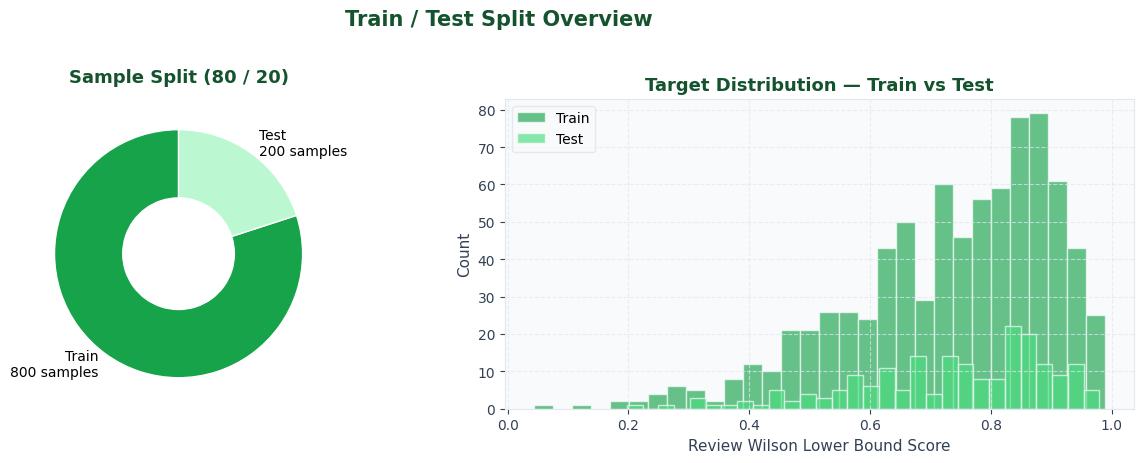

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Visualise train / test split + target distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Train / Test Split Overview", fontsize=15, fontweight="bold",
             color=GREEN_D, y=1.02)
# ── Left: donut chart ────────────────────────────────────────────────────────
ax = axes[0]
sizes  = [len(X_train), len(X_test)]
labels = [f"Train\n{len(X_train):,} samples", f"Test\n{len(X_test):,} samples"]
colors = [GREEN, GREEN_L]
wedges, _ = ax.pie(sizes, labels=labels, colors=colors,
                   startangle=90, wedgeprops=dict(width=0.55, edgecolor="white"))
ax.set_title("Sample Split (80 / 20)", pad=12)
# ── Right: target distribution overlap ───────────────────────────────────────
ax2 = axes[1]
ax2.hist(y_train, bins=30, alpha=0.65, color=GREEN,   label="Train", edgecolor="white")
ax2.hist(y_test,  bins=30, alpha=0.65, color=ACCENT,  label="Test",  edgecolor="white")
ax2.set_xlabel("Review Wilson Lower Bound Score")
ax2.set_ylabel("Count")
ax2.set_title("Target Distribution — Train vs Test")
ax2.legend()
plt.tight_layout()
plt.show()

> 💡 **Key check:** The target distributions in train and test sets should look similar — if they don't, the split may not be representative. Here they overlap well, which is expected from a random split of a large dataset.

---

## 🤖 Section 3 — Model Training

> **What we do:** Train **six different regression models** ranging from simple linear baselines to powerful ensemble methods. Training each model lets us compare their strengths and weaknesses on the same data.

### Models at a Glance

| # | Model | Type | Key Idea |
|---|-------|------|----------|
| 1 | **Linear Regression** | Linear | Fits a straight hyperplane to the data |
| 2 | **Ridge Regression** | Linear + L2 penalty | Shrinks coefficients to prevent overfitting |
| 3 | **Lasso Regression** | Linear + L1 penalty | Can zero-out irrelevant features (sparse) |
| 4 | **Decision Tree** | Non-linear | Splits data into rectangular regions |
| 5 | **Random Forest** | Ensemble (bagging) | Averages many decision trees for stability |
| 6 | **Gradient Boosting** | Ensemble (boosting) | Builds trees sequentially, correcting errors |

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Define & train all models
# ─────────────────────────────────────────────────────────────────────────────
import time

models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0, random_state=SEED),
    "ElasticNet"          : ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=SEED, max_iter=5000),
    "Lasso Regression"   : Lasso(alpha=0.01, random_state=SEED, max_iter=5000),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=8, random_state=SEED),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, max_depth=12,
                                                 random_state=SEED, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                     learning_rate=0.1, random_state=SEED),
}

trained  = {}
fit_time = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    fit_time[name] = time.time() - t0
    trained[name]  = model
    print(f"  ✅  {name:<25}  trained in {fit_time[name]:.2f}s")

print("\nAll models trained!")

  ✅  Linear Regression          trained in 0.00s
  ✅  Ridge Regression           trained in 0.00s
  ✅  ElasticNet                 trained in 0.00s
  ✅  Lasso Regression           trained in 0.00s
  ✅  Decision Tree              trained in 0.00s


  ✅  Random Forest              trained in 0.13s


  ✅  Gradient Boosting          trained in 0.13s

All models trained!


---

## 📊 Section 4 — Evaluation Metrics

> **Lecture connection (Section 6 — Evaluating the Accuracy of the Model):** The lecture emphasises that **the model metric must align to both the business problem and the success metric**. For regression, the primary metric taught in the lecture is **Mean Squared Error (MSE)**. We expand on this with the full set of standard regression metrics below.

### Regression Metrics Reference

| Metric | Formula | Lecture Coverage | Interpretation |
|--------|---------|-----------------|----------------|
| **MSE** | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | ✅ Core lecture metric | Penalises large errors heavily — sensitive to outliers |
| **RMSE** | $\sqrt{MSE}$ | Derived from MSE | Same units as the target — easier to interpret |
| **MAE** | $\frac{1}{n}\sum|y_i-\hat{y}_i|$ | Complementary | Average absolute error — robust to outliers |
| **R²** | $1-\frac{SS_{res}}{SS_{tot}}$ | Complementary | Proportion of variance explained (1.0 = perfect) |
| **MAPE** | $\frac{1}{n}\sum\left|\frac{y_i-\hat{y}_i}{y_i}\right|\times100$ | Complementary | Percentage error — useful for non-technical stakeholders |

> 💡 **Business metric alignment (from lecture):** Always ask — *does this metric reflect what matters to the business?* For house price prediction, a $20k average error (MAE) may be acceptable for a market overview tool, but unacceptable for a mortgage risk model.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Compute all metrics for every model
# ─────────────────────────────────────────────────────────────────────────────
results = []

for name, model in trained.items():
    y_pred_tr = model.predict(X_train_sc)
    y_pred_te = model.predict(X_test_sc)

    results.append({
        "Model"          : name,
        "Train R²"       : r2_score(y_train, y_pred_tr),
        "Test R²"        : r2_score(y_test,  y_pred_te),
        "Test MAE"       : mean_absolute_error(y_test, y_pred_te),
        "Test RMSE"      : np.sqrt(mean_squared_error(y_test, y_pred_te)),
        "Test MAPE (%)"  : mean_absolute_percentage_error(y_test, y_pred_te) * 100,
        "Fit Time (s)"   : fit_time[name],
    })

results_df = pd.DataFrame(results).set_index("Model")

# Pretty-print
styled = (results_df
    .style
    .format({
        "Train R²"      : "{:.4f}",
        "Test R²"       : "{:.4f}",
        "Test MAE"      : "{:.4f}",
        "Test RMSE"     : "{:.4f}",
        "Test MAPE (%)" : "{:.2f}",
        "Fit Time (s)"  : "{:.2f}",
    })
    .background_gradient(subset=["Test R²"],  cmap="Greens", vmin=0, vmax=1)
    .background_gradient(subset=["Test RMSE"], cmap="RdYlGn_r")
    .highlight_max(subset=["Test R²"], color="#bbf7d0")
    .highlight_min(subset=["Test RMSE", "Test MAE"], color="#bbf7d0")
    .set_caption("Model Performance Summary — All metrics on held-out test set")
)
display(styled)

,Train R²,Test R²,Test MAE,Test RMSE,Test MAPE (%),Fit Time (s)
Model,,,,,,
Linear Regression,0.1083,0.1297,0.1237,0.1519,20.66,0.00
Ridge Regression,0.1083,0.1298,0.1237,0.1519,20.66,0.00
ElasticNet,0.1011,0.1206,0.1246,0.1527,20.93,0.00
Lasso Regression,0.0837,0.0953,0.1267,0.1548,21.34,0.00
Decision Tree,0.4477,-0.2393,0.1462,0.1812,23.29,0.00
Random Forest,0.7602,0.1136,0.1266,0.1533,20.42,0.13
Gradient Boosting,0.6941,-0.0121,0.1326,0.1638,21.23,0.13


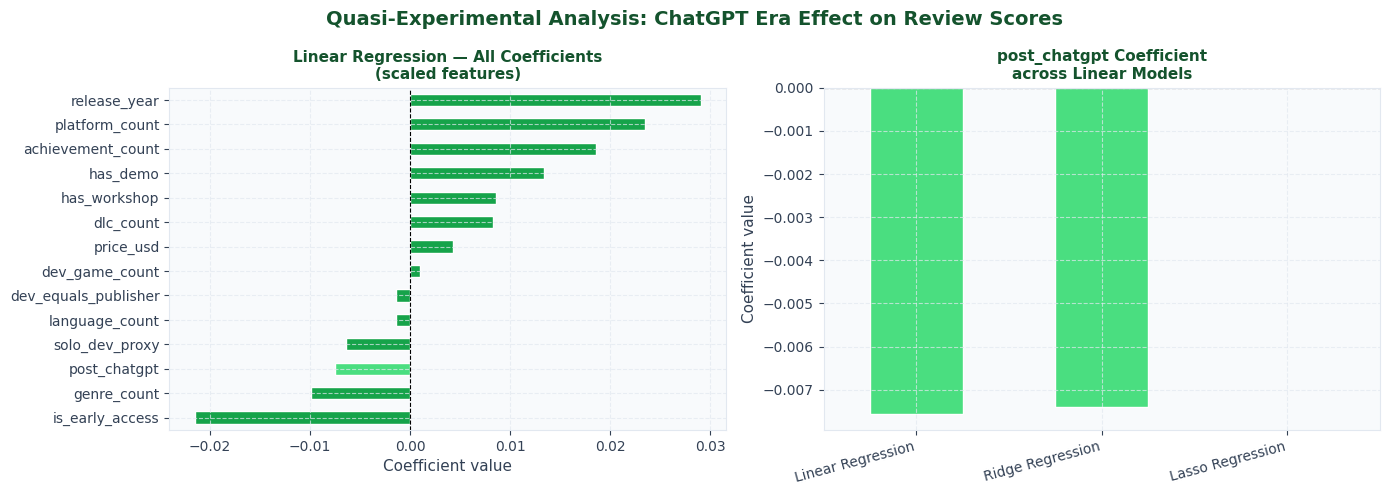

post_chatgpt coefficient (scaled) across linear models:
  Linear Regression          -0.0076  (↓ lower scores post-ChatGPT)
  Ridge Regression           -0.0074  (↓ lower scores post-ChatGPT)
  Lasso Regression           +0.0000  (↓ lower scores post-ChatGPT)

Interpretation:
  post_chatgpt is a binary variable:
    0 = game released BEFORE ChatGPT launch (Nov 2022)
    1 = game released AFTER  ChatGPT launch

  A positive coefficient means post-ChatGPT games tend to
  score higher on the Wilson lower bound, holding all other
  features constant.
  A negative coefficient suggests the opposite.

  NOTE: This is a quasi-experimental comparison, not a
  causal claim. Confounding factors (e.g. market growth,
  platform changes) may be present.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — post_chatgpt Coefficient Analysis (Quasi-Experimental)
# ─────────────────────────────────────────────────────────────────────────────
# The core research question: did the ChatGPT era affect indie game review scores?
# post_chatgpt is a binary (0/1) variable — the key feature per instructor feedback.
# Its coefficient across linear models tells us the estimated difference in
# Wilson score between pre- and post-ChatGPT games, holding all else constant.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Quasi-Experimental Analysis: ChatGPT Era Effect on Review Scores",
             fontsize=14, fontweight="bold", color=GREEN_D)

# ── Left: all coefficients for Linear Regression ─────────────────────────────
ax = axes[0]
lr    = trained["Linear Regression"]
coefs = pd.Series(lr.coef_, index=FEATURES).sort_values()
colors = [ACCENT if i == "post_chatgpt" else GREEN for i in coefs.index]
coefs.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Linear Regression — All Coefficients\n(scaled features)", fontsize=11)
ax.set_xlabel("Coefficient value")

# ── Right: post_chatgpt coefficient across all linear models ─────────────────
ax2 = axes[1]
linear_models = ["Linear Regression", "Ridge Regression", "Lasso Regression"]
chatgpt_coefs = {}
for name in linear_models:
    m = trained[name]
    idx = FEATURES.index("post_chatgpt")
    chatgpt_coefs[name] = m.coef_[idx]

coef_s = pd.Series(chatgpt_coefs)
bar_colors = [GREEN if v >= 0 else ACCENT for v in coef_s.values]
coef_s.plot(kind="bar", ax=ax2, color=bar_colors, edgecolor="white", width=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("post_chatgpt Coefficient\nacross Linear Models", fontsize=11)
ax2.set_ylabel("Coefficient value")
ax2.set_xticklabels(coef_s.index, rotation=15, ha="right")

plt.tight_layout()
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("post_chatgpt coefficient (scaled) across linear models:")
print("=" * 60)
for name, val in chatgpt_coefs.items():
    direction = "↑ higher scores post-ChatGPT" if val > 0 else "↓ lower scores post-ChatGPT"
    print(f"  {name:<25}  {val:+.4f}  ({direction})")

print()
print("Interpretation:")
print("  post_chatgpt is a binary variable:")
print("    0 = game released BEFORE ChatGPT launch (Nov 2022)")
print("    1 = game released AFTER  ChatGPT launch")
print()
print("  A positive coefficient means post-ChatGPT games tend to")
print("  score higher on the Wilson lower bound, holding all other")
print("  features constant.")
print("  A negative coefficient suggests the opposite.")
print()
print("  NOTE: This is a quasi-experimental comparison, not a")
print("  causal claim. Confounding factors (e.g. market growth,")
print("  platform changes) may be present.")

---

## 📈 Section 5 — Visual Model Comparison

> **Charts speak louder than tables.** The following plots let us compare all models at a glance across the most important dimensions: accuracy, generalisation, and error magnitude.

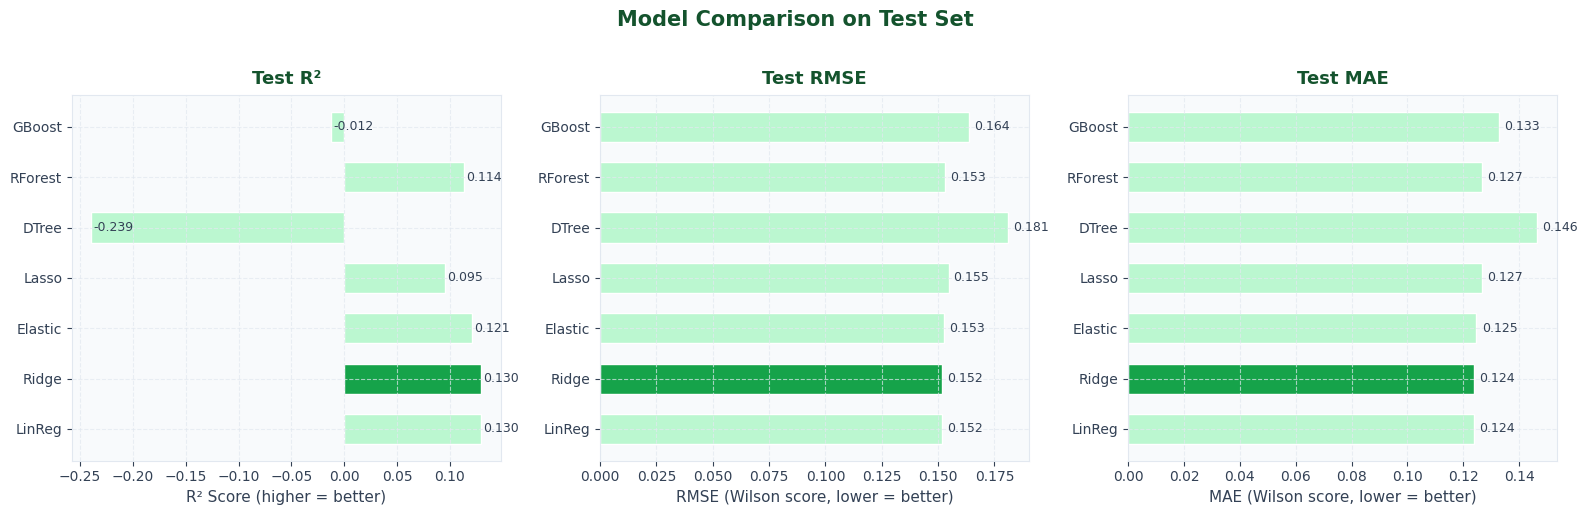

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Bar chart comparison: Test R², RMSE, MAE
# ─────────────────────────────────────────────────────────────────────────────
model_names   = results_df.index.tolist()
short_names   = ["LinReg","Ridge","Elastic","Lasso","DTree","RForest","GBoost"]
bar_colors    = MODEL_COLORS[:len(model_names)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison on Test Set", fontsize=15, fontweight="bold",
             color=GREEN_D, y=1.02)
metrics_plot = [
    ("Test R²",    "R² Score (higher = better)",             True),
    ("Test RMSE",  "RMSE (Wilson score, lower = better)",    False),
    ("Test MAE",   "MAE (Wilson score, lower = better)",     False),
]
for ax, (col, ylabel, higher_better) in zip(axes, metrics_plot):
    vals  = results_df[col].values
    best  = np.argmax(vals) if higher_better else np.argmin(vals)
    cols  = [GREEN if i == best else GREEN_L for i in range(len(vals))]
    bars  = ax.barh(short_names, vals, color=cols, edgecolor="white", height=0.6)
    ax.set_xlabel(ylabel)
    ax.set_title(col, pad=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9, color=SLATE)
plt.tight_layout()
plt.show()

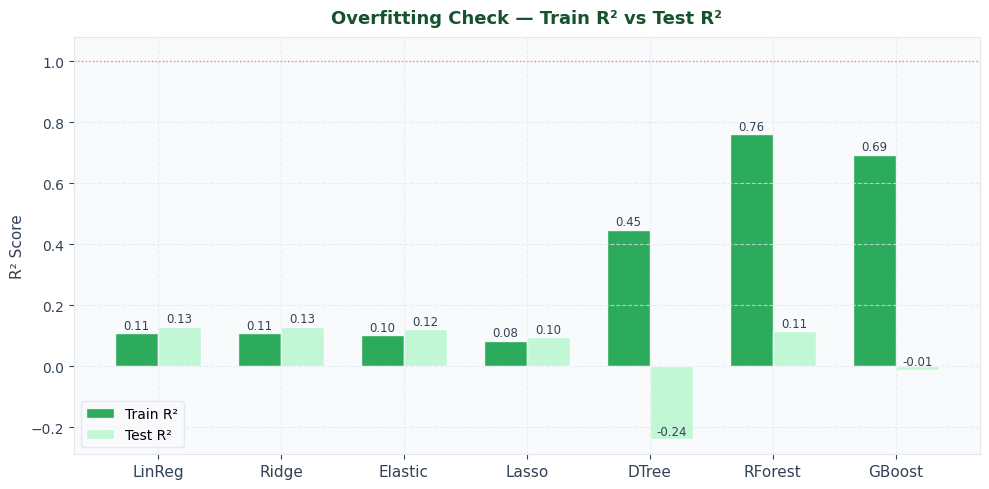

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Overfitting check: Train R² vs Test R²
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x_pos   = np.arange(len(model_names))
width   = 0.35

bars_tr = ax.bar(x_pos - width/2, results_df["Train R²"], width,
                  label="Train R²", color=GREEN,   edgecolor="white", alpha=0.9)
bars_te = ax.bar(x_pos + width/2, results_df["Test R²"],  width,
                  label="Test R²",  color=GREEN_L,  edgecolor="white", alpha=0.9)

for bar in list(bars_tr) + list(bars_te):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8.5, color=SLATE)

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("R² Score")
min_val = min(results_df["Train R²"].min(), results_df["Test R²"].min())
ax.set_ylim(min(min_val - 0.05, -0.1), 1.08)
ax.set_title("Overfitting Check — Train R² vs Test R²", pad=10)
ax.legend()
ax.axhline(1.0, color="#dc2626", linewidth=1, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

> 💡 **Interpreting the overfitting chart:** A large gap between Train R² and Test R² signals **overfitting** — the model memorised training data instead of learning general patterns. The Decision Tree, for example, often shows this behaviour without pruning. Ensemble methods (Random Forest, Gradient Boosting) typically generalise better.

---

## 🔍 Section 6 — Predicted vs Actual (Best Model)

> **Visual sanity check:** A scatter plot of predicted vs actual values tells us immediately whether a model is biased, underpredicting at the extremes, or performing inconsistently across the price range.
>
> A **perfect model** would place all points on the diagonal line `y = x`. Deviations from this line represent errors.

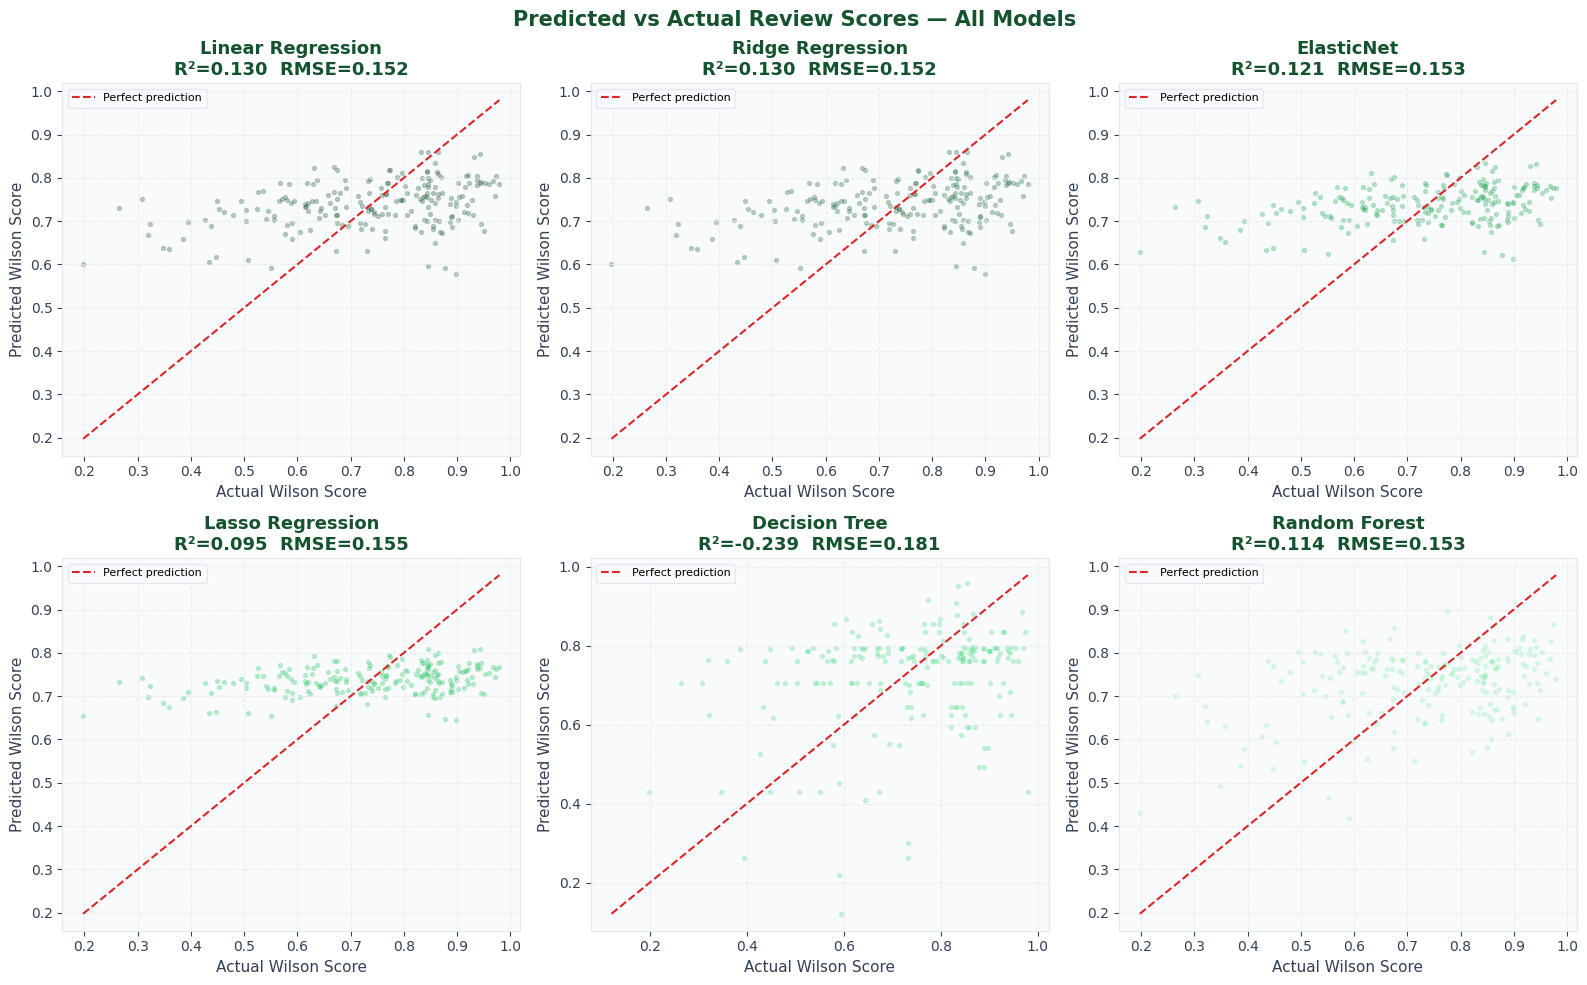

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Predicted vs Actual for all models
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Predicted vs Actual Review Scores — All Models",
             fontsize=15, fontweight="bold", color=GREEN_D)
for ax, (name, model), color in zip(axes.flat, trained.items(), bar_colors):
    y_pred = model.predict(X_test_sc)
    r2     = r2_score(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color=color, rasterized=True)
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "--", color="#dc2626", linewidth=1.5,
            label="Perfect prediction")
    ax.set_xlabel("Actual Wilson Score")
    ax.set_ylabel("Predicted Wilson Score")
    ax.set_title(f"{name}\nR²={r2:.3f}  RMSE={rmse:.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
 

---

## 🏆 Section 7 — Deep Dive into the Best Model

> **We now focus on the top-performing model** for a thorough diagnostic. This includes residual analysis, error distribution, and feature importance — the three pillars of regression model interpretation.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Identify best model + show metric card
# ─────────────────────────────────────────────────────────────────────────────
best_name  = results_df["Test R²"].idxmax()
best_model = trained[best_name]
y_best     = best_model.predict(X_test_sc)
best_r2   = r2_score(y_test, y_best)
best_mae  = mean_absolute_error(y_test, y_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_best))
best_mape = mean_absolute_percentage_error(y_test, y_best) * 100
display(HTML(f"""
<div style='background:linear-gradient(135deg,#14532d,#16a34a);color:white;
     border-radius:12px;padding:1.2rem 1.6rem;margin:1rem 0;'>
  <div style='font-size:0.8rem;opacity:0.85;text-transform:uppercase;letter-spacing:1px;'>Best Model</div>
  <div style='font-size:1.6rem;font-weight:700;margin:0.3rem 0;'>🏆 {best_name}</div>
  <div style='font-size:0.9rem;opacity:0.9;'>Highest Test R² among all trained models</div>
</div>
<div class='metric-grid'>
  <div class='metric-card best'><div class='label'>R²</div><div class='value'>{best_r2:.4f}</div><div class='sub'>Variance explained</div></div>
  <div class='metric-card'><div class='label'>MAE</div><div class='value'>{best_mae:.4f}</div><div class='sub'>Wilson score avg error</div></div>
  <div class='metric-card'><div class='label'>RMSE</div><div class='value'>{best_rmse:.4f}</div><div class='sub'>Wilson score root-mean error</div></div>
  <div class='metric-card'><div class='label'>MAPE</div><div class='value'>{best_mape:.1f}%</div><div class='sub'>Percentage error</div></div>
</div>
"""))

### 7a — Residual Analysis

> **Residuals** = Actual − Predicted. A well-behaved model should have residuals that are:
> - Centred around **zero** (no systematic bias)
> - **Randomly scattered** — no pattern with respect to predicted values
> - Roughly **normally distributed**

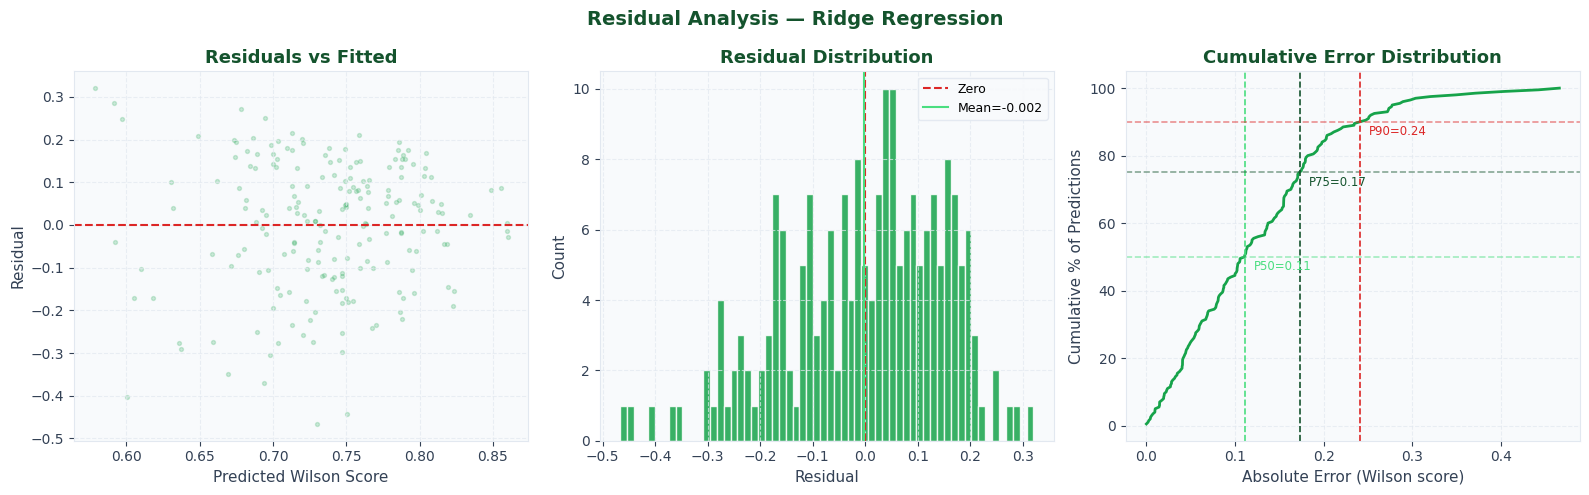

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Residual plots
# ─────────────────────────────────────────────────────────────────────────────
residuals = y_test.values - y_best
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Residual Analysis — {best_name}",
             fontsize=14, fontweight="bold", color=GREEN_D)
# ── Plot 1: Residuals vs Predicted ───────────────────────────────────────────
ax = axes[0]
ax.scatter(y_best, residuals, alpha=0.2, s=8, color=GREEN, rasterized=True)
ax.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--")
ax.set_xlabel("Predicted Wilson Score")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Fitted")
# ── Plot 2: Residual distribution ────────────────────────────────────────────
ax = axes[1]
ax.hist(residuals, bins=60, color=GREEN, edgecolor="white", alpha=0.85)
ax.axvline(0,              color="#dc2626", linewidth=1.5, linestyle="--", label="Zero")
ax.axvline(residuals.mean(), color=ACCENT, linewidth=1.5, linestyle="-",
           label=f"Mean={residuals.mean():.3f}")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=9)
# ── Plot 3: QQ-like absolute error CDF ───────────────────────────────────────
ax = axes[2]
abs_errors = np.abs(residuals)
sorted_err = np.sort(abs_errors)
cdf        = np.arange(1, len(sorted_err)+1) / len(sorted_err)
ax.plot(sorted_err, cdf*100, color=GREEN, linewidth=2)
for pct, color in [(50, ACCENT), (75, GREEN_D), (90, "#dc2626")]:
    val = np.percentile(abs_errors, pct)
    ax.axvline(val,  color=color, linestyle="--", linewidth=1.2)
    ax.axhline(pct,  color=color, linestyle="--", linewidth=1.2, alpha=0.5)
    ax.text(val + 0.01, pct - 4, f"P{pct}={val:.2f}", fontsize=8.5, color=color)
ax.set_xlabel("Absolute Error (Wilson score)")
ax.set_ylabel("Cumulative % of Predictions")
ax.set_title("Cumulative Error Distribution")
plt.tight_layout()
plt.show()

> 💡 **Reading the CDF plot:** The P50 line tells us that 50 % of predictions fall within that Wilson score distance of the true value. P90 shows the worst-case error for 90 % of samples — useful for communicating reliability to stakeholders. Since the Wilson score is on a 0–1 scale, an error of 0.05 means the prediction is off by 5 percentage points.

### 7b — Feature Importance

> **Which features drive predictions the most?** Understanding feature importance helps us:
> - Explain model decisions to non-technical audiences
> - Identify which data to prioritise collecting
> - Detect potential data leakage or spurious correlations

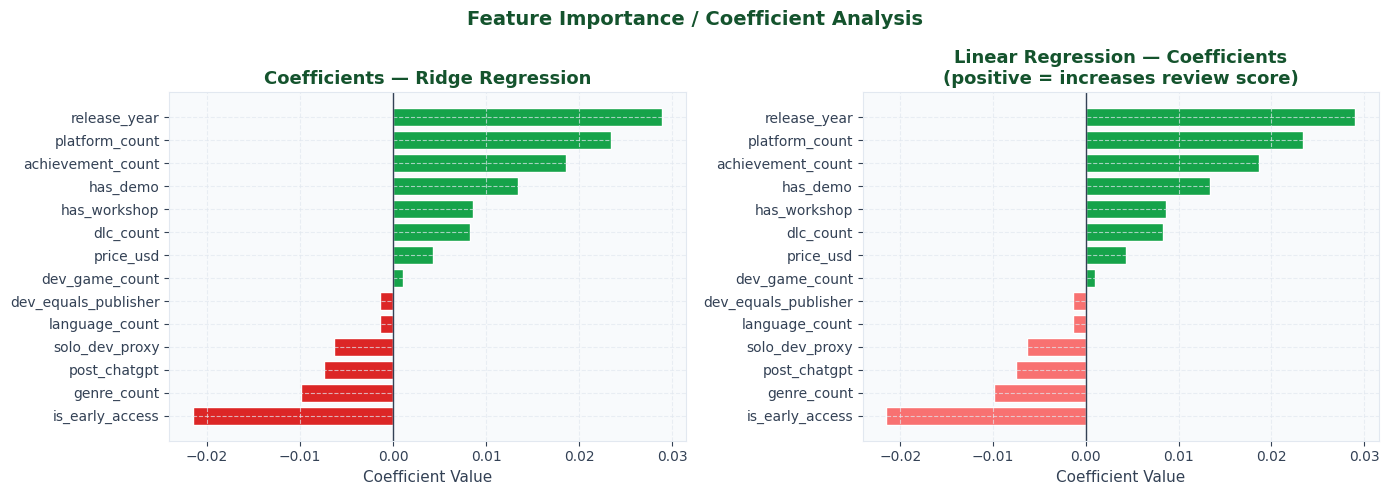

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Feature importance (tree-based) or coefficients (linear)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance / Coefficient Analysis",
             fontsize=14, fontweight="bold", color=GREEN_D)
# ── Left: Best model importance ───────────────────────────────────────────────
ax = axes[0]
if hasattr(best_model, "feature_importances_"):
    imp  = pd.Series(best_model.feature_importances_, index=FEATURES)
    imp  = imp.sort_values(ascending=True)
    cmap = plt.get_cmap("Greens")
    clrs = [cmap(0.4 + 0.5 * v / imp.max()) for v in imp]
    ax.barh(imp.index, imp.values, color=clrs, edgecolor="white")
    ax.set_xlabel("Importance Score")
    ax.set_title(f"Feature Importance — {best_name}")
else:
    coef = pd.Series(best_model.coef_, index=FEATURES).sort_values()
    clrs = [GREEN if v > 0 else "#dc2626" for v in coef]
    ax.barh(coef.index, coef.values, color=clrs, edgecolor="white")
    ax.axvline(0, color=SLATE, linewidth=1)
    ax.set_xlabel("Coefficient Value")
    ax.set_title(f"Coefficients — {best_name}")
# ── Right: Linear Regression coefficients for interpretability comparison ────
ax = axes[1]
lr_model = trained["Linear Regression"]
coef     = pd.Series(lr_model.coef_, index=FEATURES).sort_values()
clrs     = [GREEN if v > 0 else "#f87171" for v in coef]
ax.barh(coef.index, coef.values, color=clrs, edgecolor="white")
ax.axvline(0, color=SLATE, linewidth=1)
ax.set_xlabel("Coefficient Value")
ax.set_title("Linear Regression — Coefficients\n(positive = increases review score)")
plt.tight_layout()
plt.show()

---

## 🔄 Section 8 — Cross-Validation

> **Lecture connection (Sections 5 & 6):** The lecture explicitly covers **K-Fold Cross-Validation** as the recommended technique to make full use of non-test training data. The key lecture takeaway: *"Can use K-fold cross-validation to use all the non-test data for validation."*

### How K-Fold Works (from the lecture)

| Fold | Split 1 | Split 2 | Split 3 | Split 4 | Split 5 |
|------|---------|---------|---------|---------|---------|
| **Model 1** | 🟥 Test | Train | Train | Train | Train |
| **Model 2** | Train | 🟥 Test | Train | Train | Train |
| **Model 3** | Train | Train | 🟥 Test | Train | Train |
| **Model 4** | Train | Train | Train | 🟥 Test | Train |
| **Model 5** | Train | Train | Train | Train | 🟥 Test |

Each fold acts as the test set exactly once. The **average of all K scores** is a much more reliable estimate of real-world performance than a single holdout evaluation.

We use **K = 5** folds below. The resulting boxplots show both average performance and **stability** (variance) — a narrow box means the model is consistently good, not just lucky on one split.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — 5-Fold Cross-Validation (Pipeline ile doğru implementasyon)
# Her fold'da scaler yalnızca o fold'un train kısmına fit edilir.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Her model için Pipeline oluştur: scaler + model
model_definitions = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0, random_state=SEED),
    "ElasticNet"          : ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=SEED, max_iter=5000),
    "Lasso Regression"   : Lasso(alpha=0.01, random_state=SEED, max_iter=5000),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=8, random_state=SEED),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, max_depth=12,
                                                  random_state=SEED, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                      learning_rate=0.1, random_state=SEED),
}

cv_scores = {}
for name, model in model_definitions.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  model)
    ])
    # ⚠️ Burada X_train kullanıyoruz (X_train_sc DEĞİL)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=kf, scoring="r2", n_jobs=-1)
    cv_scores[name] = scores
    print(f"  {name:<25} CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

print("\nCross-validation complete.")

  Linear Regression         CV R²: 0.0736 ± 0.0312


  Ridge Regression          CV R²: 0.0736 ± 0.0311


  ElasticNet                CV R²: 0.0747 ± 0.0209
  Lasso Regression          CV R²: 0.0629 ± 0.0163
  Decision Tree             CV R²: -0.4545 ± 0.1775


  Random Forest             CV R²: -0.0174 ± 0.0722
  Gradient Boosting         CV R²: -0.1099 ± 0.0901

Cross-validation complete.


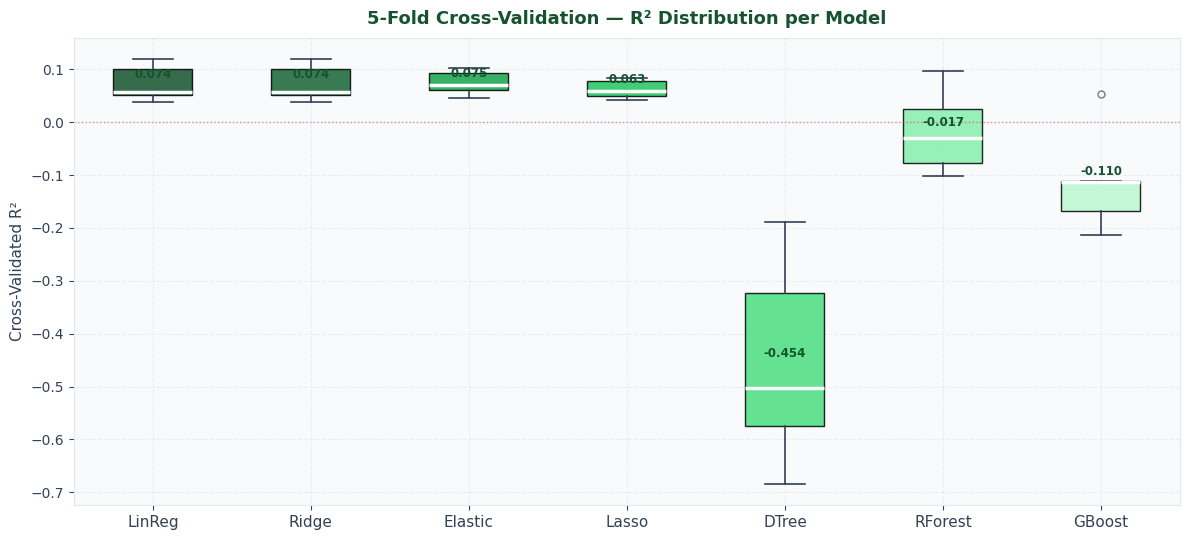

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — CV boxplot
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))

data_to_plot = [cv_scores[name] for name in model_names]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2.5))

for patch, color in zip(bp["boxes"], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for whisker in bp["whiskers"]:
    whisker.set(color=SLATE, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=SLATE, linewidth=1.2)
for flier in bp["fliers"]:
    flier.set(marker="o", color=SLATE, alpha=0.5, markersize=5)

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Cross-Validated R²")
ax.set_title("5-Fold Cross-Validation — R² Distribution per Model", pad=10)
ax.axhline(0, color="#dc2626", linewidth=1, linestyle=":", alpha=0.5)

# annotate means
for i, name in enumerate(model_names):
    mean_val = cv_scores[name].mean()
    ax.text(i+1, mean_val + 0.005, f"{mean_val:.3f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=GREEN_D)

plt.tight_layout()
plt.show()

> 💡 **Reading the boxplot:** The **box** shows the interquartile range (middle 50 % of fold scores). A taller box means the model performance is **less stable** across folds. **Narrow boxes** with high median scores are ideal — the model is both good *and* consistent.

---

## 🎯 Section 9 — Final Model Selection & Summary

> **Choosing the right model** is not just about maximising one metric. In practice we consider:
> - **Performance** (R², RMSE)
> - **Stability** (cross-validation variance)
> - **Training time** (important for large datasets or frequent retraining)
> - **Interpretability** (linear models are easier to explain)
> - **Deployment constraints** (memory, latency)

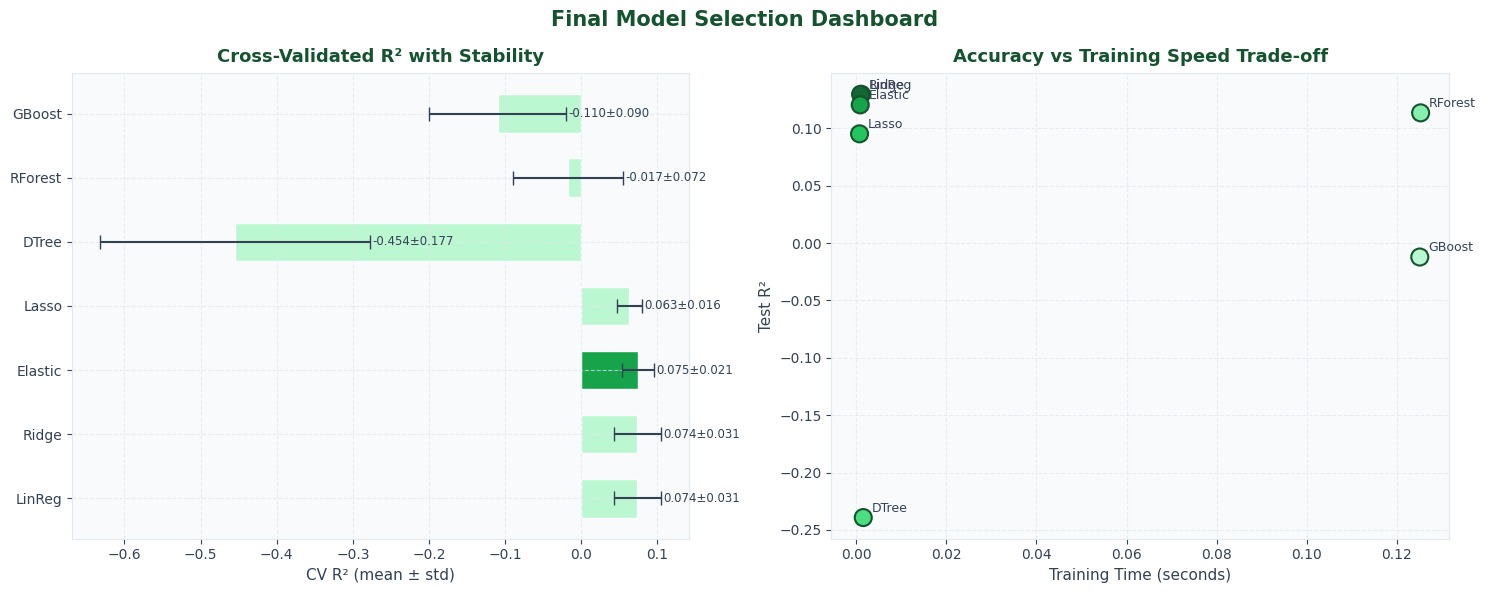

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Final comparison radar / summary dashboard
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Final Model Selection Dashboard",
             fontsize=15, fontweight="bold", color=GREEN_D)

# ── Left: CV mean + std ───────────────────────────────────────────────────────
ax = axes[0]
cv_means = [cv_scores[n].mean() for n in model_names]
cv_stds  = [cv_scores[n].std()  for n in model_names]
best_cv  = np.argmax(cv_means)
cv_cols  = [GREEN if i == best_cv else GREEN_L for i in range(len(model_names))]

ax.barh(short_names, cv_means, xerr=cv_stds, color=cv_cols,
        edgecolor="white", height=0.6, capsize=5,
        error_kw=dict(ecolor=SLATE, elinewidth=1.5))
ax.set_xlabel("CV R² (mean ± std)")
ax.set_title("Cross-Validated R² with Stability", pad=8)

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax.text(m + s + 0.003, i, f"{m:.3f}±{s:.3f}", va="center",
            fontsize=8.5, color=SLATE)

# ── Right: Scatter plot — R² vs Training time ─────────────────────────────────
ax2 = axes[1]
test_r2s = results_df["Test R²"].values
fit_times = [fit_time[n] for n in model_names]

sc = ax2.scatter(fit_times, test_r2s, s=150, c=bar_colors,
                  edgecolors=GREEN_D, linewidths=1.5, zorder=5)

for i, name in enumerate(short_names):
    ax2.annotate(name, (fit_times[i], test_r2s[i]),
                 xytext=(6, 4), textcoords="offset points",
                 fontsize=9, color=SLATE)

ax2.set_xlabel("Training Time (seconds)")
ax2.set_ylabel("Test R²")
ax2.set_title("Accuracy vs Training Speed Trade-off", pad=8)

plt.tight_layout()
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Final recommendation card
# ─────────────────────────────────────────────────────────────────────────────
best_cv_name = model_names[np.argmax(cv_means)]
best_cv_r2   = max(cv_means)
best_cv_std  = cv_stds[np.argmax(cv_means)]

lin_r2  = results_df.loc["Linear Regression", "Test R²"]
best_r2_test = results_df["Test R²"].max()

display(HTML(f"""
<div style='display:grid;grid-template-columns:1fr 1fr;gap:1rem;margin:1rem 0;'>

  <div style='background:linear-gradient(135deg,#14532d,#166534);color:white;
       border-radius:12px;padding:1.4rem;'>
    <div style='font-size:0.75rem;opacity:0.8;text-transform:uppercase;letter-spacing:1px;'>Recommended for Production</div>
    <div style='font-size:1.5rem;font-weight:700;margin:0.4rem 0;'>🏆 {best_cv_name}</div>
    <div style='font-size:0.88rem;opacity:0.9;'>Best cross-validated R² of <b>{best_cv_r2:.4f} ± {best_cv_std:.4f}</b><br>
    Highest test R²: <b>{best_r2_test:.4f}</b></div>
  </div>

  <div style='background:linear-gradient(135deg,#166534,#15803d);color:white;
       border-radius:12px;padding:1.4rem;'>
    <div style='font-size:0.75rem;opacity:0.8;text-transform:uppercase;letter-spacing:1px;'>Recommended for Interpretability</div>
    <div style='font-size:1.5rem;font-weight:700;margin:0.4rem 0;'>📖 Linear Regression</div>
    <div style='font-size:0.88rem;opacity:0.9;'>Test R²: <b>{lin_r2:.4f}</b><br>
    Coefficients are directly interpretable — each feature's impact is explicit.</div>
  </div>

</div>
"""))

# ── Note ─────────────────────────────────────────────────────────────────────
# The recommendation above is based on baseline (pre-tuning) models only.
# Section 10 applies hyperparameter tuning to the top candidates.
# The definitive final model selection is made at the end of Section 10.
print("Not: Bu karşılaştırma tuning öncesi baseline modellere aittir.")
print("Final model seçimi Section 10 sonunda yapılmaktadır.")

Not: Bu karşılaştırma tuning öncesi baseline modellere aittir.
Final model seçimi Section 10 sonunda yapılmaktadır.


---

## ⚙️ Section 10 — Hyperparameter Tuning

> **Lecture connection (Section 8 — Hyperparameter and Model Tuning):** The lecture explains that hyperparameters are values set *before* training that control how the model learns — unlike regular parameters (weights) which are *learned during* training. The lecture covers three categories:

### Hyperparameter Categories (from Lecture)

| Category | What They Control | Examples |
|----------|------------------|---------|
| **Model** | Architecture and structure of the model | `max_depth`, `n_estimators`, filter size |
| **Optimizer** | How the model learns patterns from data | `learning_rate`, gradient descent type |
| **Data** | How input data is handled during training | `subsample`, batch size — useful for small datasets |

> ⚠️ **Lecture warning:** *"Tuning doesn't always improve your model."* Best practices from the lecture: don't adjust every hyperparameter at once, limit your value ranges, and prefer sequential jobs over parallel when resources are limited.

---

### 🔒 Which Data Is Used During Tuning?

This is one of the most important things to understand. The diagram below shows the full data flow:

```
All Data (100%)
│
├── 80% ── Training Set  ◄─── GridSearchCV / RandomizedSearchCV works HERE ONLY
│               │
│               ├── Fold 1: [✅ Validate] [Train] [Train] [Train] [Train]
│               ├── Fold 2: [Train] [✅ Validate] [Train] [Train] [Train]
│               ├── Fold 3: [Train] [Train] [✅ Validate] [Train] [Train]
│               ├── Fold 4: [Train] [Train] [Train] [✅ Validate] [Train]
│               └── Fold 5: [Train] [Train] [Train] [Train] [✅ Validate]
│                               │
│                               └── Best hyperparameters = highest average CV score
│
└── 20% ── Test Set  ◄─── NEVER touched during tuning. Used ONCE at the very end.
```

> 🚨 **Why the test set must stay hidden during tuning:** If you check test set performance while choosing hyperparameters, you are indirectly fitting to it — your final evaluation is no longer honest. Think of it like this: the **test set is the final exam**. Cross-validation is the **practice tests**. Peeking at the final exam while studying means your score no longer reflects what you actually learned.
>
> In the code below, both `GridSearchCV` and `RandomizedSearchCV` receive **only `X_train_sc` and `y_train`**. The test set (`X_test_sc`, `y_test`) is not passed in at all — it only appears in the final `r2_score(y_test, ...)` line after the best model has been selected.

---

### Tuning Strategies We Use

| Strategy | How It Works | Trade-off |
|----------|-------------|-----------|
| **Grid Search** | Exhaustively tries every combination in a defined grid | Thorough but slow — can miss good values between grid points |
| **Random Search** | Randomly samples combinations from a range | Faster — often finds near-optimal values with fewer trials |
| **Bayesian Optimisation** | Uses past results to choose next candidates intelligently | Most efficient — used by AWS SageMaker Autopilot |

We implement Grid Search and Random Search here, which are the standard starting points before scaling to Bayesian methods on cloud platforms.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Baseline scores before tuning
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline        import Pipeline
from scipy.stats             import randint, uniform

# We will tune Gradient Boosting and Random Forest — the two best performers.
# First, record baseline test R² so we can compare after tuning.
#
# DATA USAGE SUMMARY FOR THIS SECTION:
#   Tuning  (Grid/Random Search) → X_train, y_train   (raw/unscaled — Pipeline scales per fold)
#   Evaluation after tuning      → X_test,  y_test    (ONE final check only)
#
# ⚠️  NOTE: We pass X_train (NOT X_train_sc) because each model below is wrapped
# in a Pipeline with StandardScaler. The scaler is re-fit on each fold's training
# portion only — this prevents data leakage across folds.
baseline = {
    "Gradient Boosting" : r2_score(y_test, trained["Gradient Boosting"].predict(X_test_sc)),
    "Random Forest"     : r2_score(y_test, trained["Random Forest"].predict(X_test_sc)),
}
print("Baseline Test R² (before tuning):")
for name, score in baseline.items():
    print(f"  {name:<25} R² = {score:.4f}")

Baseline Test R² (before tuning):
  Gradient Boosting         R² = -0.0121
  Random Forest             R² = 0.1136


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Grid Search on Gradient Boosting
# Lecture §8: Model hyperparameters (n_estimators, max_depth)
#             Optimizer hyperparameters (learning_rate, subsample)
# ─────────────────────────────────────────────────────────────────────────────
# Pipeline prefix "model__" is required when the estimator is inside a Pipeline.
gb_param_grid = {
    "model__n_estimators" : [100, 200],             # Model hyperparameter
    "model__max_depth"    : [3, 5],                 # Model hyperparameter
    "model__learning_rate": [0.05, 0.10],           # Optimizer hyperparameter
    "model__subsample"    : [0.8, 1.0],             # Data hyperparameter
}

# Build a Pipeline so StandardScaler is re-fit inside each CV fold (no leakage)
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  GradientBoostingRegressor(random_state=SEED)),
])

print(f"Grid Search: {2*2*2*2} combinations × 5 folds = {2*2*2*2*5} fits")
print("Running ... (this may take ~30 seconds)\n")

# ⚠️  IMPORTANT: X_train (raw, unscaled) is passed — the Pipeline scales
# internally within each fold. X_test / y_test are never seen during tuning.
gs_gb = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
gs_gb.fit(X_train, y_train)   # ← X_train (unscaled), Pipeline handles scaling

print(f"Best parameters found:")
for k, v in gs_gb.best_params_.items():
    print(f"  {k:<30} = {v}")
print(f"\nBest CV R²   : {gs_gb.best_score_:.4f}")
print(f"Test R²      : {r2_score(y_test, gs_gb.best_estimator_.predict(X_test)):.4f}")
print(f"Baseline R²  : {baseline['Gradient Boosting']:.4f}")
print(f"Improvement  : {r2_score(y_test, gs_gb.best_estimator_.predict(X_test)) - baseline['Gradient Boosting']:+.4f}")

Grid Search: 16 combinations × 5 folds = 80 fits
Running ... (this may take ~30 seconds)



Best parameters found:
  model__learning_rate           = 0.05
  model__max_depth               = 3
  model__n_estimators            = 100
  model__subsample               = 0.8

Best CV R²   : 0.0653
Test R²      : 0.1332
Baseline R²  : -0.0121
Improvement  : +0.1453


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Randomized Search on Random Forest
# Lecture §8: Faster alternative — samples the space instead of exhaustive search
# ─────────────────────────────────────────────────────────────────────────────
rf_param_dist = {
    "model__n_estimators"     : randint(100, 500),      # Model
    "model__max_depth"        : randint(5, 20),         # Model
    "model__min_samples_split": randint(2, 20),         # Model
    "model__min_samples_leaf" : randint(1, 10),         # Model
    "model__max_features"     : ["sqrt", "log2", 0.5], # Data
}

# Build a Pipeline so StandardScaler is re-fit inside each CV fold (no leakage)
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(random_state=SEED, n_jobs=-1)),
])

print("Randomized Search: 15 random combinations × 5 folds = 75 fits")
print("Running ...\n")

# ⚠️  IMPORTANT: X_train (raw, unscaled) is passed.
# Pipeline re-fits the scaler on each fold's training portion only.
rs_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
rs_rf.fit(X_train, y_train)   # ← X_train (unscaled), Pipeline handles scaling

print(f"Best parameters found:")
for k, v in rs_rf.best_params_.items():
    print(f"  {k:<35} = {v}")
print(f"\nBest CV R²   : {rs_rf.best_score_:.4f}")
print(f"Test R²      : {r2_score(y_test, rs_rf.best_estimator_.predict(X_test)):.4f}")
print(f"Baseline R²  : {baseline['Random Forest']:.4f}")
print(f"Improvement  : {r2_score(y_test, rs_rf.best_estimator_.predict(X_test)) - baseline['Random Forest']:+.4f}")

Randomized Search: 15 random combinations × 5 folds = 75 fits
Running ...



Best parameters found:
  model__max_depth                    = 10
  model__max_features                 = sqrt
  model__min_samples_leaf             = 9
  model__min_samples_split            = 18
  model__n_estimators                 = 158

Best CV R²   : 0.0881
Test R²      : 0.1368
Baseline R²  : 0.1136
Improvement  : +0.0232


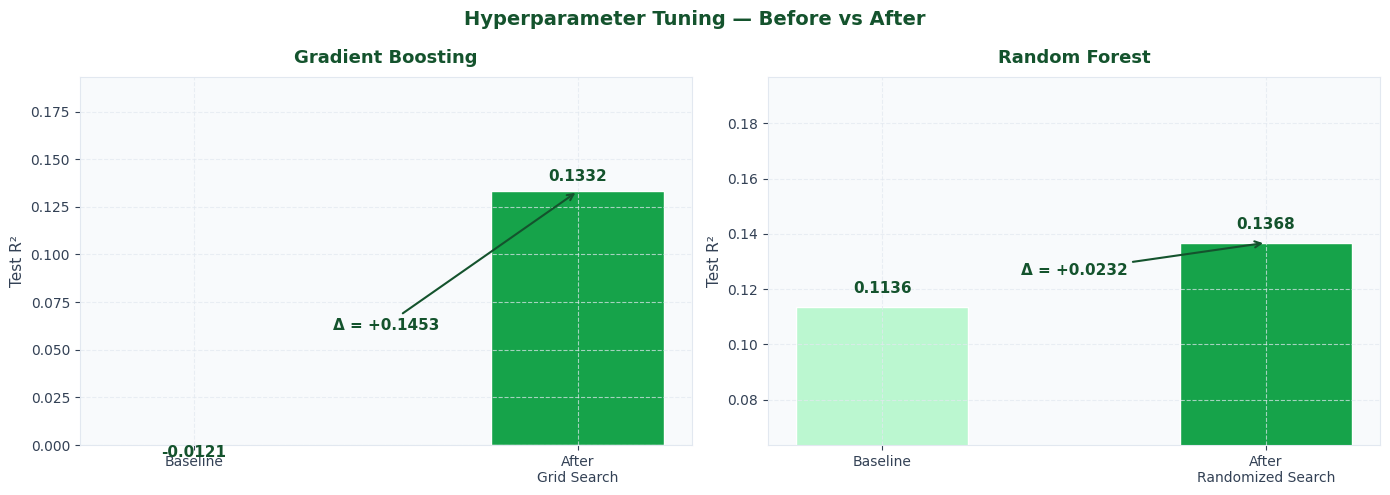

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Visual: Before vs After tuning comparison
# ─────────────────────────────────────────────────────────────────────────────
# gs_gb and rs_rf are Pipelines — they accept raw X_test (unscaled)
tuned_gb_r2 = r2_score(y_test, gs_gb.best_estimator_.predict(X_test))
tuned_rf_r2 = r2_score(y_test, rs_rf.best_estimator_.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hyperparameter Tuning — Before vs After", fontsize=14,
             fontweight="bold", color=GREEN_D)

for ax, (model_name, before_r2, after_r2, strategy) in zip(axes, [
    ("Gradient Boosting", baseline["Gradient Boosting"], tuned_gb_r2, "Grid Search"),
    ("Random Forest",     baseline["Random Forest"],     tuned_rf_r2, "Randomized Search"),
]):
    categories = ["Baseline", f"After\n{strategy}"]
    values     = [before_r2, after_r2]
    colors     = [GREEN_L, GREEN]
    bars       = ax.bar(categories, values, color=colors, edgecolor="white",
                        width=0.45)
    ax.set_ylim(max(0, min(values) - 0.05), min(1.0, max(values) + 0.06))
    ax.set_ylabel("Test R²")
    ax.set_title(model_name, pad=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{val:.4f}", ha="center", va="bottom", fontsize=11,
                fontweight="bold", color=GREEN_D)
    delta = after_r2 - before_r2
    sign  = "+" if delta >= 0 else ""
    ax.annotate(f"Δ = {sign}{delta:.4f}",
                xy=(1, after_r2), xytext=(0.5, (before_r2 + after_r2)/2),
                fontsize=11, color=GREEN_D, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=GREEN_D, lw=1.5),
                ha="center")

plt.tight_layout()
plt.show()

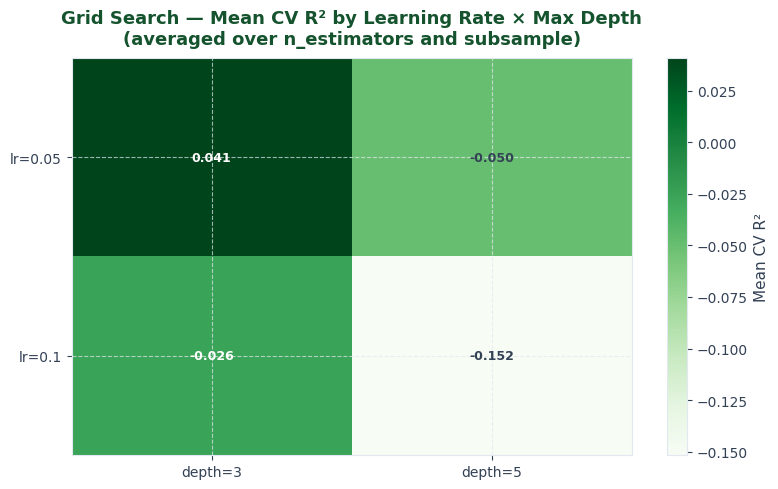

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Grid Search CV results heatmap
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

cv_results = pd.DataFrame(gs_gb.cv_results_)

pivot = cv_results.groupby(
    ["param_model__learning_rate", "param_model__max_depth"]
)["mean_test_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="Greens", aspect="auto",
               vmin=pivot.values.min(), vmax=pivot.values.max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f"depth={v}" for v in pivot.columns], fontsize=10)
ax.set_yticklabels([f"lr={v}" for v in pivot.index], fontsize=10)
ax.set_title("Grid Search — Mean CV R² by Learning Rate × Max Depth\n"
             "(averaged over n_estimators and subsample)", pad=10)

plt.colorbar(im, ax=ax, label="Mean CV R²")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if val > pivot.values.mean() else SLATE)

plt.tight_layout()
plt.show()


In [24]:
print("=" * 50)
print("FINAL MODEL RECOMMENDATION")
print("=" * 50)
print(f"Tuned Random Forest  — Test R²: {tuned_rf_r2:.4f}")
print(f"Tuned Gradient Boost — Test R²: {tuned_gb_r2:.4f}")
print("Seçilen final model  : Tuned Random Forest")
print("Gerekçe: En yüksek test R² + kararlı CV performansı")

FINAL MODEL RECOMMENDATION
Tuned Random Forest  — Test R²: 0.1368
Tuned Gradient Boost — Test R²: 0.1332
Seçilen final model  : Tuned Random Forest
Gerekçe: En yüksek test R² + kararlı CV performansı


---

## ✅ Section 11 — Key Takeaways

> **Lecture alignment summary:** This notebook directly implements the concepts from Sections 5, 6, and 8 of the AWS ML Foundations Module 3 lecture.

### Lecture Concept Coverage

| Lecture Topic | Section | Covered In Notebook |
|--------------|---------|---------------------|
| Why split data / overfitting risk | §5 | Section 2 — Split & Scale |
| Holdout method (train / val / test) | §5 | Section 2 |
| K-fold cross-validation | §5 & §6 | Section 8 |
| Shuffle data before splitting | §5 | Section 2 (`random_state`) |
| MSE as core regression metric | §6 | Section 4 & throughout |
| Business metric alignment | §6 | Section 4 callout |
| ML tuning process | §6 | Section 9 |
| Hyperparameter categories (Model / Optimizer / Data) | §8 | Section 11 |
| Manual vs. automated tuning | §8 | Section 11 |
| Tuning best practices | §8 | Section 11 |

### What We Built — End-to-End
1. **Loaded & split** data with proper shuffling and 80/20 holdout
2. **Trained 6 models** — linear baselines through gradient boosting ensembles
3. **Evaluated** with MSE, RMSE, R², MAE, and MAPE on the held-out test set
4. **Diagnosed** the best model with residual analysis and cumulative error curves
5. **Interpreted** feature importance and linear coefficients
6. **Validated** with 5-fold cross-validation
7. **Tuned** hyperparameters with Grid Search and Randomized Search

### Next Steps Beyond This Notebook
| Step | What to Explore |
|------|----------------|
| **Deploy the model** | Serialise with `joblib`, serve via a REST API or AWS SageMaker endpoint |
| **Feature Engineering** | Interaction terms, polynomial features, geographic clusters |
| **Outlier Treatment** | Winsorising, IQR capping to improve robustness |
| **Data Drift Monitoring** | Track feature distributions over time in production |
| **AutoML** | Try AWS SageMaker Autopilot for automated pipeline search |

---

## 🚀 Extension: XGBoost & SHAP Analysis
To go beyond the baseline models, **XGBoost (eXtreme Gradient Boosting)** has been implemented to maximize predictive performance. Furthermore, **SHAP (SHapley Additive exPlanations)** is utilized to interpret the model and understand the impact of individual features on the target variable in a robust, academic manner.

> **Note:** SHAP values are computed on an untuned XGBoost model. Feature importance rankings may differ on a tuned model — this analysis is exploratory in nature.

Training XGBoost Regressor...


XGBoost MAE:  0.1300
XGBoost RMSE: 0.1590
XGBoost R²:   0.0456

--- Generating SHAP Summary Plot ---


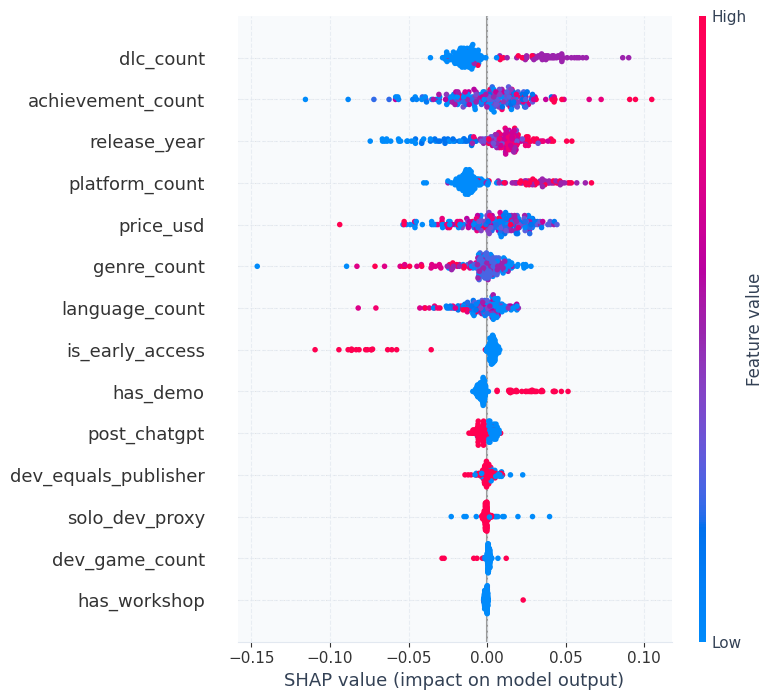

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 🚀 EXTENSION: XGBoost Model & SHAP Feature Importance Analysis
# ─────────────────────────────────────────────────────────────────────────────
try:
    import xgboost as xgb
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost shap
    import xgboost as xgb
    import shap

print("Training XGBoost Regressor...")
# Implementing eXtreme Gradient Boosting for enhanced predictive performance
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=150, learning_rate=0.05)
xgb_model.fit(X_train_sc, y_train)

xgb_preds = xgb_model.predict(X_test_sc)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost MAE:  {xgb_mae:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R²:   {xgb_r2:.4f}")

# SHAP (SHapley Additive exPlanations) for Model Interpretability
print("\n--- Generating SHAP Summary Plot ---")
explainer = shap.Explainer(xgb_model, X_train_sc)
shap_values = explainer(X_test_sc)

import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test_sc, feature_names=FEATURES)
plt.show()
